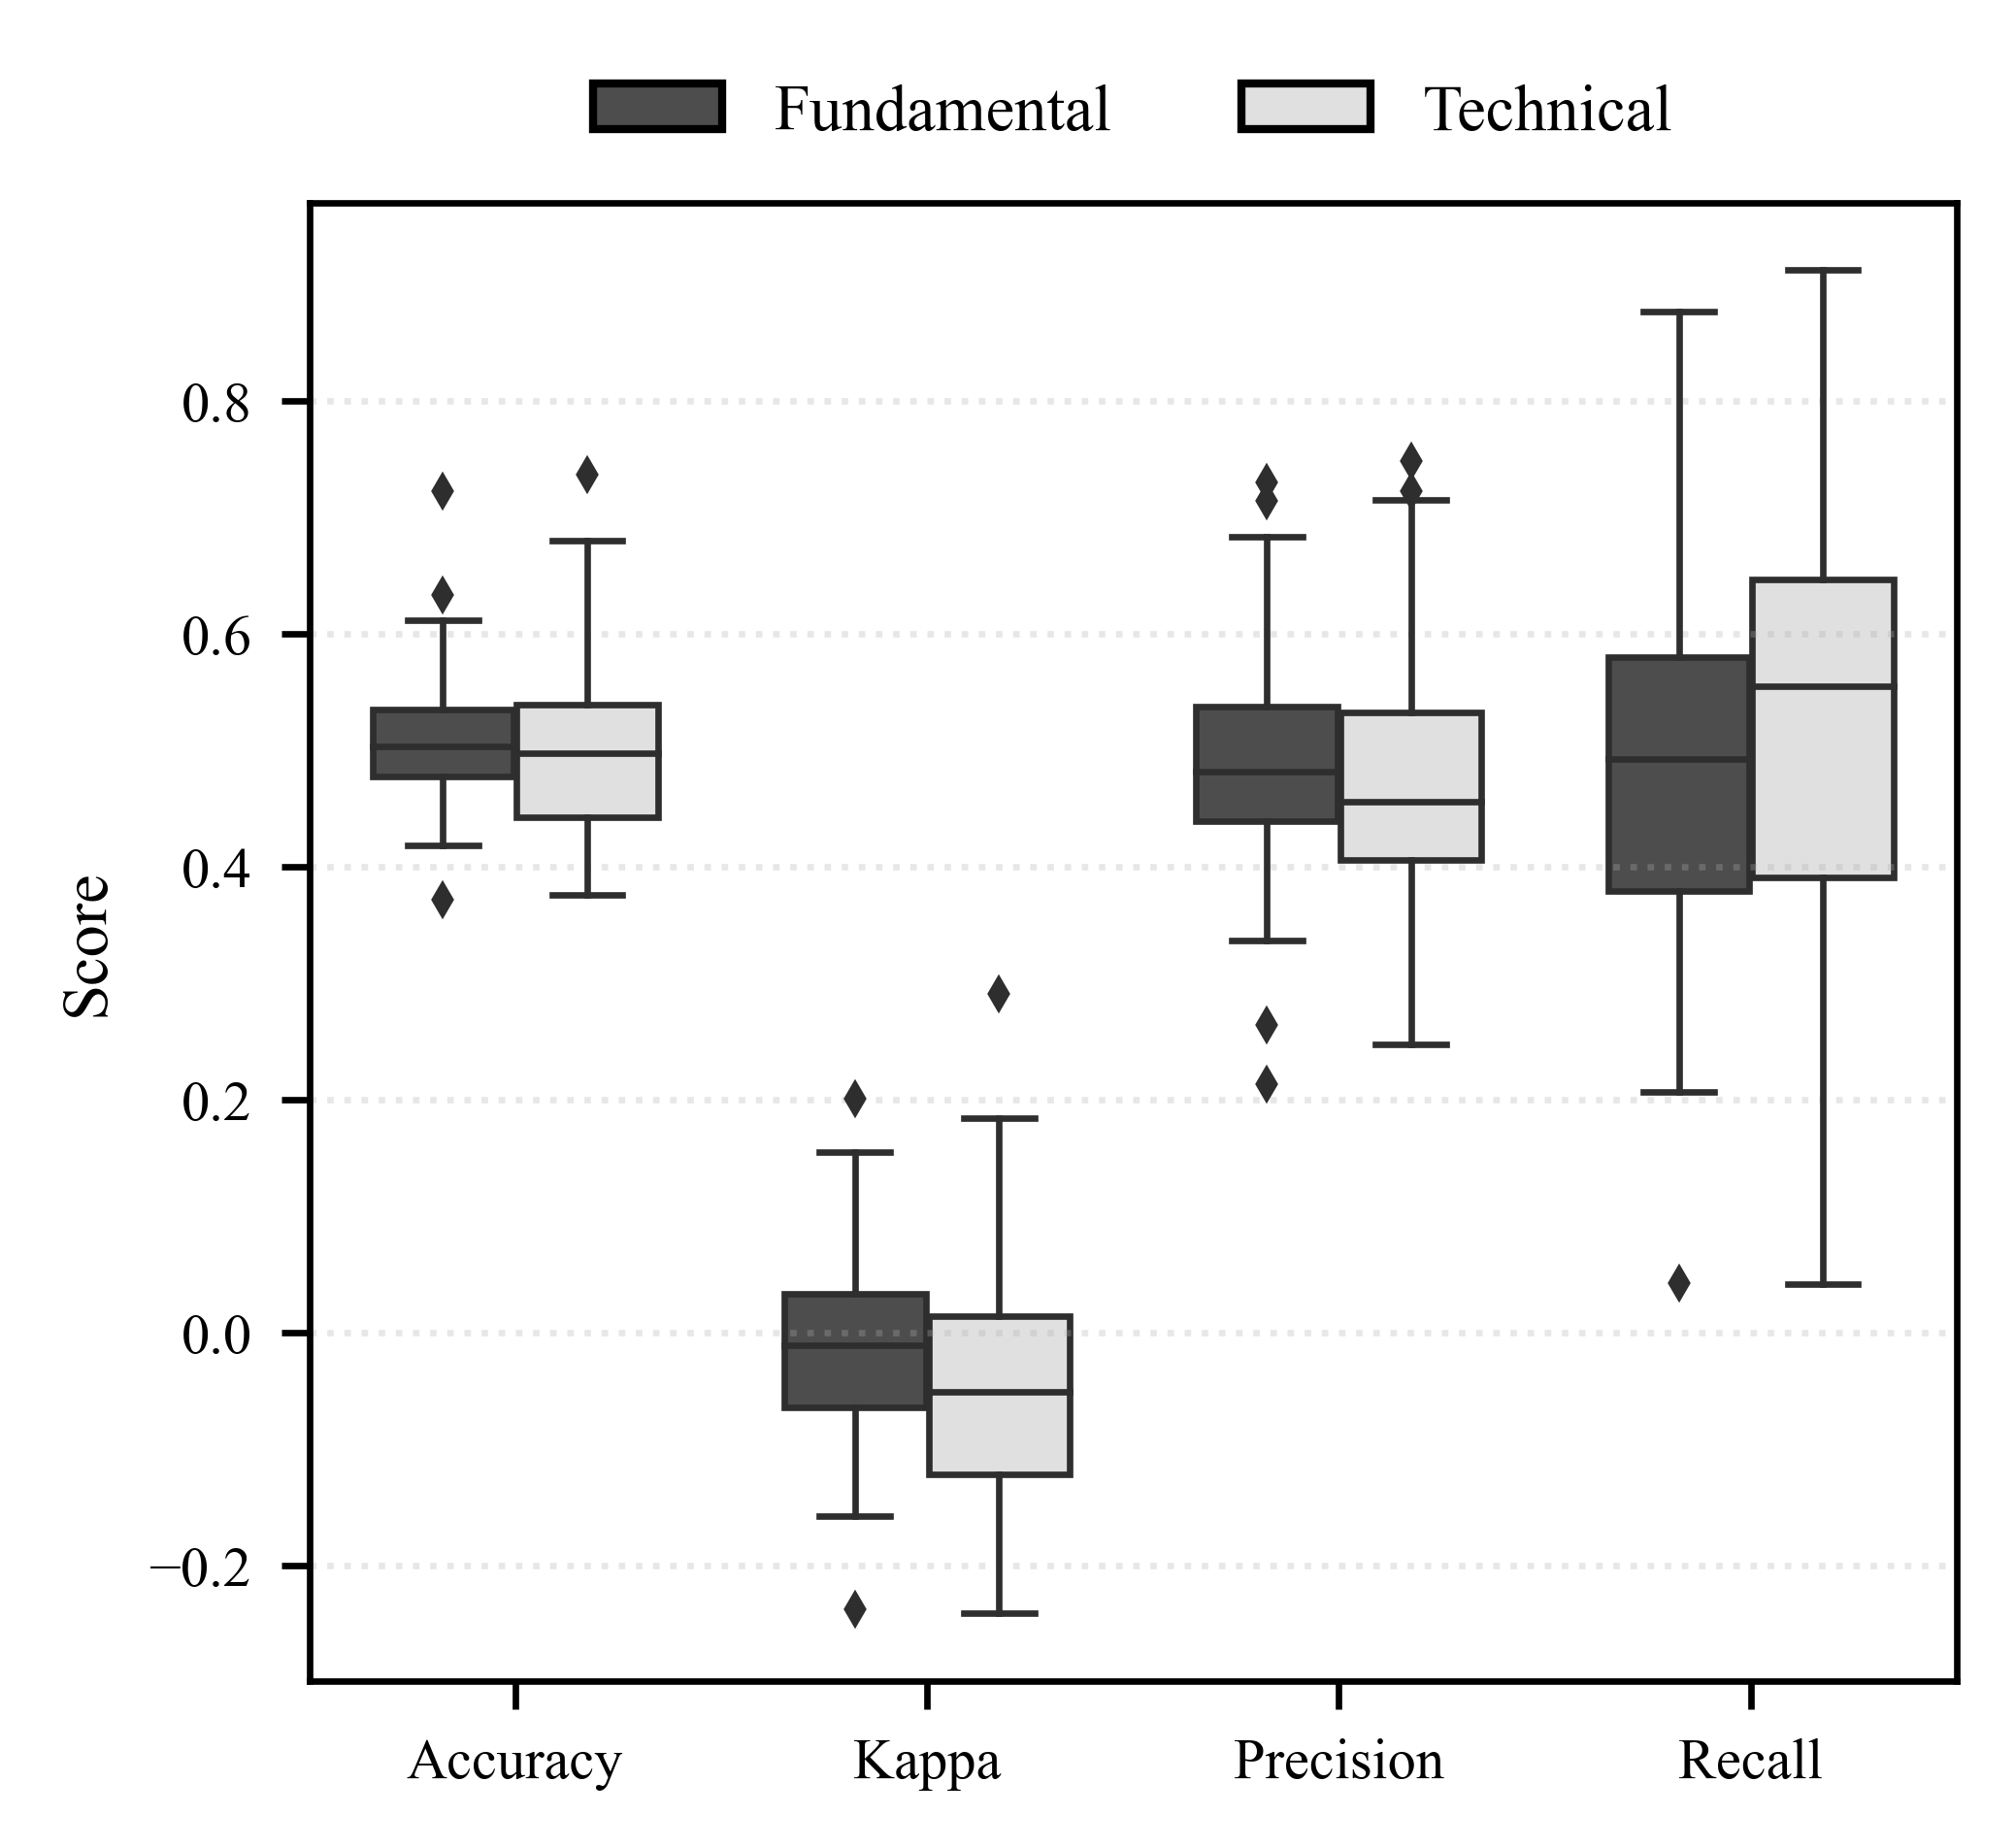

[INFO] Plot saved to: figures/metrics_distribution_lag1.pdf

STATISTICAL PERFORMANCE REPORT BY DOMAIN
Initial Asset Count (in results CSV): 64
FINAL Asset Count (after 2023/LEVE3 filters): 58
Considered Assets: ABCB4, ALPA4, AMER3, BBAS3, BBDC3, BBDC4, BEEF3, BRFS3, BRSR6, CCRO3, CIEL3, CMIG3, CMIG4, CPFE3, CSUD3, CYRE3, DIRR3, DXCO3, ELET3, ELET6, EMBR3, ENBR3, EQTL3, FESA4, FHER3, GFSA3, GGBR3, GGBR4, GRND3, HBOR3, HYPE3, ITUB3, ITUB4, KEPL3, LOGN3, LREN3, MDIA3, MILS3, MULT3, MYPK3, NEXP3, ODPV3, PDGR3, PETR3, PETR4, POMO4, POSI3, RADL3, RENT3, RSID3, SAPR4, SLCE3, TOTS3, TRPL4, UNIP6, USIM3, USIM5, VALE3
--------------------------------------------------------------------------------

>>> METRIC: ACCURACY
Domain        Fundamental  Technical
N                 58.0000    58.0000
Mean               0.5105     0.4990
Std_Dev            0.0603     0.0758
Min                0.3713     0.3753
Q1 (25%)           0.4770     0.4418
Median (50%)       0.5031     0.4974
Q3 (75%)           0.5

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import matplotlib.font_manager as fm
from matplotlib.patches import Patch

# ==============================================================================
# 1. FONT AND STYLE CONFIGURATION (IEEE STANDARD)
# ==============================================================================
possible_paths = [
    os.path.expanduser('~/.local/share/fonts/times.ttf'),
    os.path.expanduser('~/.local/share/fonts/Times New Roman.ttf'),
    '/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman.ttf',
    'C:/Windows/Fonts/times.ttf'
]

font_path = None
for p in possible_paths:
    if os.path.exists(p):
        font_path = p
        break

try:
    if font_path:
        fm.fontManager.addfont(font_path)
        font_prop = fm.FontProperties(fname=font_path)
        exact_font_name = font_prop.get_name()
    else:
        exact_font_name = 'serif'
except Exception:
    exact_font_name = 'serif'

# IEEE Configurations
IEEE_COL_WIDTH = 3.5
IEEE_HEIGHT = 3.2 

plt.rcParams.update({
    'font.family': exact_font_name,
    'font.size': 8,
    'axes.labelsize': 8,
    'axes.titlesize': 9,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'figure.dpi': 600,
    'lines.linewidth': 0.8,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': ':'
})

palette_map = {'Fundamental': '#4D4D4D', 'Technical': '#E0E0E0'}

# ==============================================================================
# 2. LOADING AND METRIC CALCULATION (PER ASSET)
# ==============================================================================
file_path = 'results/results_HT_delay_1.csv' 
domain_map = {'fund': 'Fundamental', 'nao_fund': 'Technical'}

# Variables for counting
initial_asset_count = 0
final_asset_count = 0
final_asset_list = []

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    
    # Initial count (before filters)
    if 'dataset' in df.columns:
        initial_asset_count = df['dataset'].nunique()

    # --- FILTERING ---
    try:
        df_stock = pd.read_csv('/home/jjos/profit_performance/valor_mobiliario.csv')
        if not pd.api.types.is_datetime64_any_dtype(df_stock['Data_Referencia']):
            df_stock['Data_Referencia'] = pd.to_datetime(df_stock['Data_Referencia'], errors='coerce')

        # Assets present in 2023
        valid_tickers = df_stock[df_stock['Data_Referencia'].dt.year == 2023].Codigo_Negociacao.unique()
        
        # Filters
        df = df[df['dataset'].isin(valid_tickers)]
        df = df[~df['dataset'].isin(['LEVE3'])] # Explicit exclusion
        
        # Final count
        final_asset_count = df['dataset'].nunique()
        final_asset_list = df['dataset'].unique()
        
    except Exception as e:
        print(f"[ERROR] Asset filtering failed: {e}")
        if 'dataset' in df.columns:
            final_asset_count = df['dataset'].nunique()

    # Map domain names
    df['Domain'] = df['category'].map(domain_map)
    
    # Group by Asset (dataset) and Domain
    df_assets = df.groupby(['dataset', 'Domain'])[['TP', 'TN', 'FP', 'FN']].sum().reset_index()
    
    # Metric Calculations
    total = df_assets['TP'] + df_assets['TN'] + df_assets['FP'] + df_assets['FN']
    
    df_assets['Accuracy'] = (df_assets['TP'] + df_assets['TN']) / total
    
    # Precision
    df_assets['Precision'] = df_assets['TP'] / (df_assets['TP'] + df_assets['FP'])
    df_assets['Precision'] = df_assets['Precision'].fillna(0)
    
    # Recall
    df_assets['Recall'] = df_assets['TP'] / (df_assets['TP'] + df_assets['FN'])
    df_assets['Recall'] = df_assets['Recall'].fillna(0)
    
    # Kappa
    po = df_assets['Accuracy']
    pe_pos = ((df_assets['TP'] + df_assets['FP']) * (df_assets['TP'] + df_assets['FN'])) / (total**2)
    pe_neg = ((df_assets['TN'] + df_assets['FN']) * (df_assets['TN'] + df_assets['FP'])) / (total**2)
    pe = pe_pos + pe_neg
    df_assets['Kappa'] = (po - pe) / (1 - pe)
    
else:
    print("[WARNING] File not found. Using simulated data format (empty).")
    df_assets = pd.DataFrame() 

# ==============================================================================
# 3. PLOTTING (BOXPLOT)
# ==============================================================================
if not df_assets.empty:
    metrics_to_plot = ['Accuracy', 'Kappa', 'Precision', 'Recall']
    df_melted = df_assets.melt(id_vars=['dataset', 'Domain'], 
                               value_vars=metrics_to_plot, 
                               var_name='Metric', value_name='Score')

    fig, ax = plt.subplots(figsize=(IEEE_COL_WIDTH, IEEE_HEIGHT))

    sns.boxplot(
        data=df_melted, x='Metric', y='Score', hue='Domain',
        palette=palette_map,
        linewidth=0.8,
        fliersize=2,
        saturation=1,
        width=0.7,
        ax=ax
    )

    ax.set_xlabel('')
    ax.set_ylabel('Score')
    ax.set_title('')

    handles = [Patch(facecolor=palette_map['Fundamental'], edgecolor='black', label='Fundamental'),
               Patch(facecolor=palette_map['Technical'], edgecolor='black', label='Technical')]

    ax.legend(handles=handles, labels=['Fundamental', 'Technical'], 
              loc='upper center', bbox_to_anchor=(0.5, 1.12), 
              ncol=2, frameon=False, fontsize=8)

    plt.tight_layout()
    
    # Ensure directory exists before saving
    os.makedirs('figures', exist_ok=True)
    output_filename = 'figures/metrics_distribution_lag1.pdf'
    plt.savefig(output_filename, format='pdf', dpi=600, bbox_inches='tight')
    plt.show()
    print(f"[INFO] Plot saved to: {output_filename}")

# ==============================================================================
# 4. DETAILED STATISTICAL REPORT
# ==============================================================================
print("\n" + "="*80)
print("STATISTICAL PERFORMANCE REPORT BY DOMAIN")
print("="*80)

# 1. Asset Counting
print(f"Initial Asset Count (in results CSV): {initial_asset_count}")
print(f"FINAL Asset Count (after 2023/LEVE3 filters): {final_asset_count}")
if final_asset_count > 0:
    print(f"Considered Assets: {', '.join(sorted(final_asset_list))}")
print("-" * 80)

stats_df = pd.DataFrame()

if not df_assets.empty:
    # 2. Descriptive statistics calculation
    metrics_cols = ['Accuracy', 'Kappa', 'Precision', 'Recall']
    stats_df = df_assets.groupby('Domain')[metrics_cols].describe(percentiles=[0.25, 0.5, 0.75])

    # 3. Formatting and Printing
    for metric in metrics_cols:
        print(f"\n>>> METRIC: {metric.upper()}")
        
        subset = stats_df[metric]
        
        subset = subset.rename(columns={
            'count': 'N',
            'mean': 'Mean',
            'std': 'Std_Dev',
            'min': 'Min',
            '25%': 'Q1 (25%)',
            '50%': 'Median (50%)',
            '75%': 'Q3 (75%)',
            'max': 'Max'
        })
        
        print(subset.T.to_string(float_format="{:.4f}".format))
        print("-" * 40)

    # 4. Dispersion Analysis (IQR)
    print("\n>>> DISPERSION ANALYSIS (IQR = Q3 - Q1)")
    iqr_data = []
    for metric in metrics_cols:
        subset = stats_df[metric]
        iqr_fund = subset.loc['Fundamental', '75%'] - subset.loc['Fundamental', '25%']
        iqr_tech = subset.loc['Technical', '75%'] - subset.loc['Technical', '25%']
        iqr_data.append({'Metric': metric, 'IQR Fundamental': iqr_fund, 'IQR Technical': iqr_tech})
    
    df_iqr = pd.DataFrame(iqr_data)
    print(df_iqr.to_string(index=False, float_format="{:.4f}".format))

print("="*80 + "\n")

# ==============================================================================
# 5. SAVE REPORT TO CSV
# ==============================================================================
if not stats_df.empty:
    print("\n[INFO] Generating CSV report...")
    
    report_csv = stats_df.stack(level=0, future_stack=True).reset_index() if hasattr(stats_df, 'future_stack') else stats_df.stack(level=0).reset_index()
    
    report_csv = report_csv.rename(columns={
        'level_1': 'Metric',
        'count': 'Count',
        'mean': 'Mean',
        'std': 'Std_Dev',
        'min': 'Min',
        '25%': 'Q1',
        '50%': 'Median',
        '75%': 'Q3',
        'max': 'Max'
    })
    
    cols_order = ['Domain', 'Metric', 'Count', 'Mean', 'Median', 'Std_Dev', 'Min', 'Q1', 'Q3', 'Max']
    report_csv = report_csv[cols_order]
    
    csv_filename = 'descriptive_statistics_report.csv'
    report_csv.to_csv(csv_filename, index=False, float_format='%.4f')
    
    print(f"[SUCCESS] Report saved to: {os.path.abspath(csv_filename)}")
    print("="*80)
else:
    print("[WARNING] No data available to save.")